In [45]:
#importing libraries for data visualisation and manipulation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Plot formatting
plt.style.use('ggplot')
sns.set_palette("husl")
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [46]:
#loading the datasets

df_trades = pd.read_csv("historical_data.csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader Data Shape:", df_trades.shape)
print("Sentiment Data Shape:", df_sentiment.shape)

display(df_trades.head())
display(df_sentiment.head())

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [47]:
#Exploratory_Data_Analysis(EDA). 

df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [48]:
df_trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [49]:
df_sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [50]:
df_trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [51]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [52]:
df_trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [53]:
#CELL 3: DATA CLEANING & MERGING

df_trades['Date'] = pd.to_datetime(df_trades['Timestamp IST'], format='mixed', dayfirst=True).dt.date
df_sentiment['Date'] = pd.to_datetime(df_sentiment['date']).dt.date
#MERGING THE DATASETS
df_merged = pd.merge(df_trades, df_sentiment, on='Date', how='left')

print("Merge Successful!")
print(f"Total Trades after merge: {df_merged.shape[0]}")
print(f"Missing Classification values now: {df_merged['classification'].isnull().sum()}")


display(df_merged.head())

Merge Successful!
Total Trades after merge: 211224
Missing Classification values now: 6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [54]:
#Sort by date and forward-fill missing classifications
df_merged = df_merged.sort_values(by='Date')
df_merged['classification'] = df_merged['classification'].ffill().bfill()

In [57]:
print(df_merged.isnull().sum()) 
print(df_merged.shape)

                                          Account Coin  Execution Price  \
83771  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1898.6   
83769  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
83770  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  ETH           1897.9   
39063  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41866.0   
39062  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  BTC          41867.0   

       Size Tokens  Size USD  Side     Timestamp IST  Start Position  \
83771      0.07220    137.08   BUY  01-05-2023 01:06          0.1791   
83769      0.09670    183.53   BUY  01-05-2023 01:06          0.0000   
83770      0.08240    156.39   BUY  01-05-2023 01:06          0.0967   
39063      0.58211  24370.62  SELL  05-12-2023 03:11         -0.0150   
39062      0.01500    628.00  SELL  05-12-2023 03:11          0.0000   

        Direction  Closed PnL  ...    Order ID  Crossed       Fee  \
83771   Open Long         0.0  ...   173271100 

In [58]:
#Dropping the unnecessary columns from the data-frame. 

cols_to_drop = ['Timestamp IST', 'Transaction Hash', 'Order ID', 'Trade ID', 'Timestamp', 'timestamp', 'date']
df_merged = df_merged.drop(columns=[col for col in cols_to_drop if col in df_merged.columns])

In [60]:
df_merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Date,value,classification
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,0.1791,Open Long,0.0,True,0.000000,2023-05-01,63.0,Greed
83769,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,0.0000,Open Long,0.0,True,0.000000,2023-05-01,63.0,Greed
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,0.0967,Open Long,0.0,True,0.000000,2023-05-01,63.0,Greed
39063,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,-0.0150,Open Short,0.0,True,6.092654,2023-12-05,75.0,Extreme Greed
39062,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,0.0000,Open Short,0.0,True,0.157001,2023-12-05,75.0,Extreme Greed


In [61]:
df_merged.shape

(211224, 14)

In [62]:
df_merged.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Start Position     0
Direction          0
Closed PnL         0
Crossed            0
Fee                0
Date               0
value              6
classification     0
dtype: int64

In [63]:
df_merged['value'] = df_merged['value'].ffill().bfill()
df_merged.isnull().sum()

Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Start Position     0
Direction          0
Closed PnL         0
Crossed            0
Fee                0
Date               0
value              0
classification     0
dtype: int64

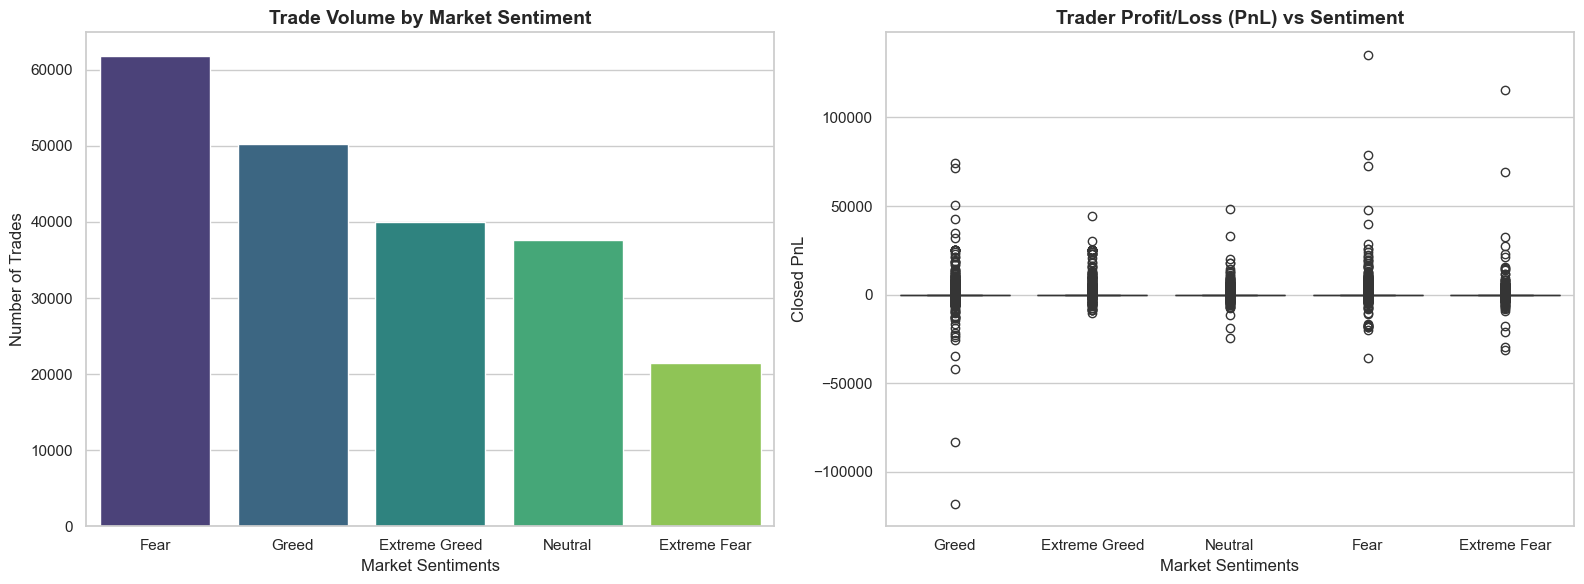


--- Average PnL by Market Sentiment ---
classification
Extreme Fear     34.54
Extreme Greed    67.89
Fear             54.29
Greed            43.58
Neutral          34.31
Name: Closed PnL, dtype: float64


In [64]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: How many trades happen during different sentiments
sns.countplot(data=df_merged, x='classification', palette='viridis', ax=axes[0], 
              order=df_merged['classification'].value_counts().index)
axes[0].set_title('Trade Volume by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiments')
axes[0].set_ylabel('Number of Trades')

# Plot 2: How does PnL change with Sentiments
sns.boxplot(data=df_merged, x='classification', y='Closed PnL', palette='viridis', ax=axes[1])
axes[1].set_title('Trader Profit/Loss (PnL) vs Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiments')
axes[1].set_ylabel('Closed PnL')



plt.tight_layout()
plt.show()

# Print actual average numbers
print("\n--- Average PnL by Market Sentiment ---")
print(df_merged.groupby('classification')['Closed PnL'].mean().round(2))

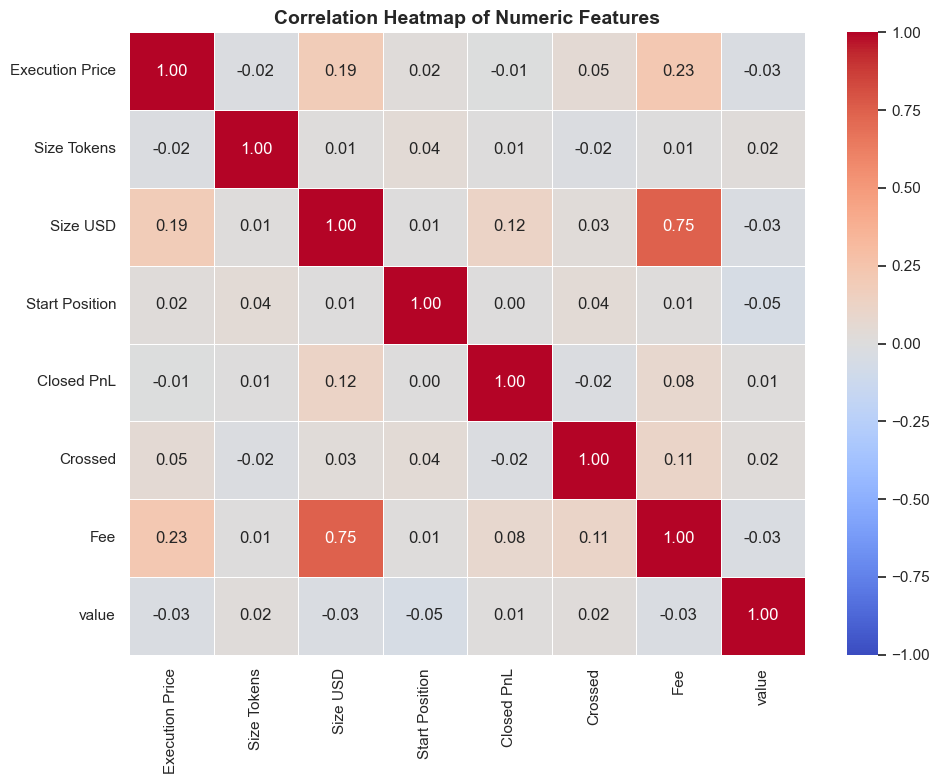

Correlation with Closed PnL:
Closed PnL         1.000000
Size USD           0.123589
Fee                0.084020
value              0.008320
Size Tokens        0.005068
Start Position     0.004066
Execution Price   -0.006505
Crossed           -0.017773
Name: Closed PnL, dtype: float64


In [65]:
#CORRELATION HEATMAP

#Selecting only numeric columns for correlation (ignoring text/categorical columns for now)
numeric_cols = df_merged.select_dtypes(include=['number', 'bool']).columns
corr_matrix = df_merged[numeric_cols].corr()

#Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#how each feature correlates with our target (Closed PnL)
print("Correlation with Closed PnL:")
print(corr_matrix['Closed PnL'].sort_values(ascending=False))

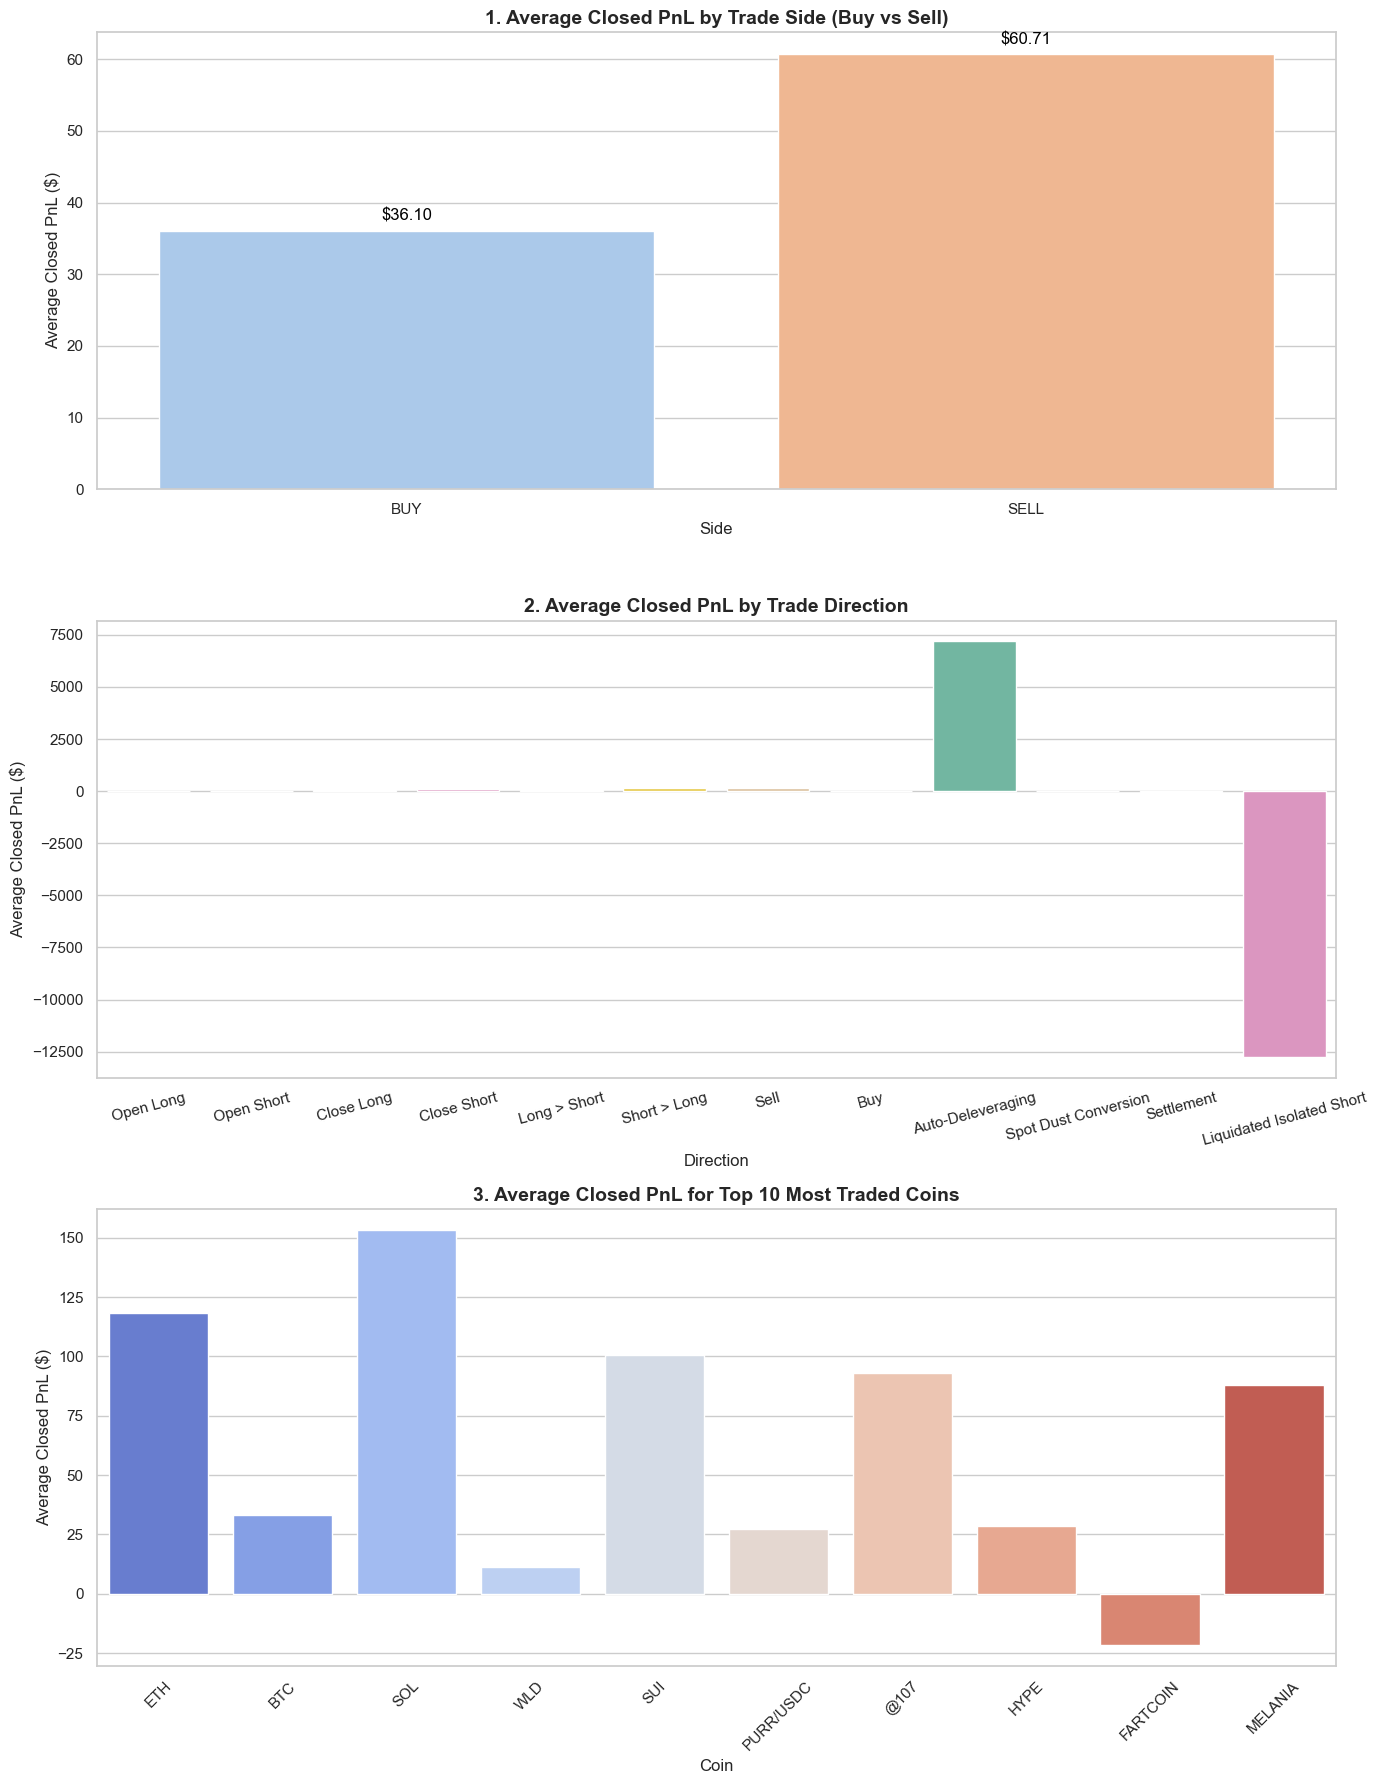

--- Quick Insights ---
Average PnL by Side:
Side
BUY     36.10
SELL    60.71
Name: Closed PnL, dtype: float64
Direction
Auto-Deleveraging             7184.81
Buy                              0.00
Close Long                      74.43
Close Short                    103.01
Liquidated Isolated Short   -12752.91
Long > Short                    34.94
Open Long                        0.00
Open Short                       0.00
Sell                           146.05
Settlement                     -29.22
Short > Long                   154.19
Spot Dust Conversion             0.00
Name: Closed PnL, dtype: float64


In [67]:
#PnL RELATIONSHIP WITH CATEGORICAL FEATURES


fig, axes = plt.subplots(3, 1, figsize=(14, 18))

#Side vs Average Closed PnL
sns.barplot(data=df_merged, x='Side', y='Closed PnL', ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('1. Average Closed PnL by Trade Side (Buy vs Sell)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Closed PnL ($)')
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')


#Direction vs Average Closed PnL
sns.barplot(data=df_merged, x='Direction', y='Closed PnL', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('2. Average Closed PnL by Trade Direction', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Closed PnL ($)')
axes[1].tick_params(axis='x', rotation=15)

#Most Traded Coins vs Average Closed PnL
top_coins = df_merged['Coin'].value_counts().nlargest(10).index
df_top_coins = df_merged[df_merged['Coin'].isin(top_coins)]

sns.barplot(data=df_top_coins, x='Coin', y='Closed PnL', ax=axes[2], palette='coolwarm', errorbar=None)
axes[2].set_title('3. Average Closed PnL for Top 10 Most Traded Coins', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Average Closed PnL ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print quick insights
print("--- Quick Insights ---")
print("Average PnL by Side:")
print(df_merged.groupby('Side')['Closed PnL'].mean().round(2))
print(df_merged.groupby('Direction')['Closed PnL'].mean().round(2))

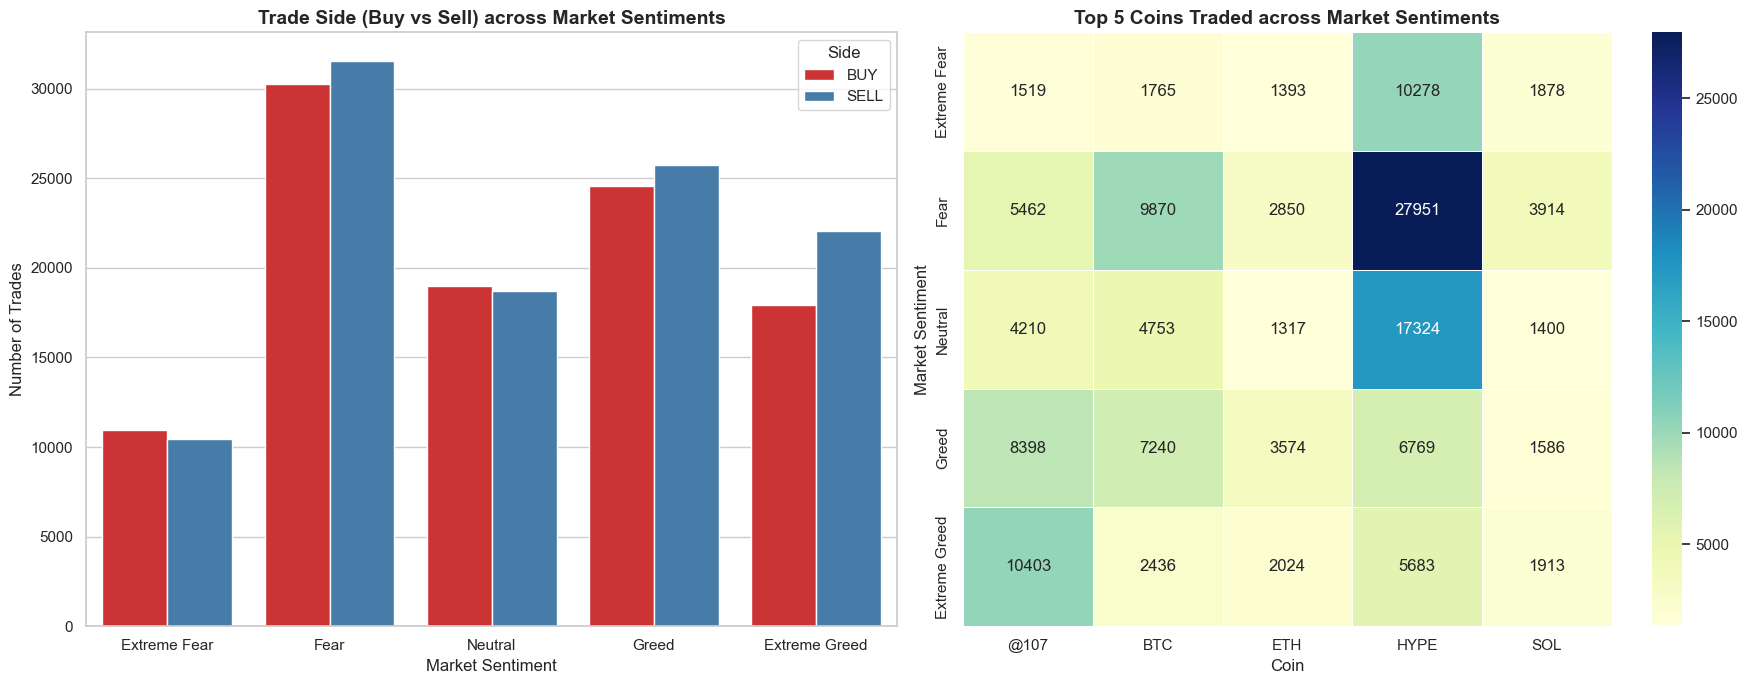

--- Sentiment vs Trade Side ---
Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24582  25727
Neutral         18969  18717


In [68]:
#BEHAVIORAL ANALYSIS (Sentiment vs Side & Coins)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Sentiment vs Trade Side (Buy/Sell)
#Let's count how many Buys and Sells happen in each sentiment
sns.countplot(data=df_merged, x='classification', hue='Side', palette='Set1', ax=axes[0], 
              order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
axes[0].set_title('Trade Side (Buy vs Sell) across Market Sentiments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Number of Trades')


#Finding the top 5 most traded coins
top_5_coins = df_merged['Coin'].value_counts().nlargest(5).index
df_top5 = df_merged[df_merged['Coin'].isin(top_5_coins)]

#crosstab for the heatmap
ct = pd.crosstab(df_top5['classification'], df_top5['Coin'])
ct = ct.reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], linewidths=0.5)
axes[1].set_title('Top 5 Coins Traded across Market Sentiments', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coin')
axes[1].set_ylabel('Market Sentiment')

plt.tight_layout()
plt.show()


print("--- Sentiment vs Trade Side ---")
print(pd.crosstab(df_merged['classification'], df_merged['Side']))

In [69]:
#FEATURE ENGINEERING

#Target Variable: Predict if trade is Profitable (1) or Loss/Zero (0)
df_merged['Is_Profitable'] = (df_merged['Closed PnL'] > 0).astype(int)

#Sentiments to Numeric Score
sentiment_mapping = {'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5}
df_merged['Sentiment_Score'] = df_merged['classification'].map(sentiment_mapping)

#Handling Trade Size (Log Transform to handle outliers)
df_merged['Log_Size_USD'] = np.log1p(df_merged['Size USD'])

#Time Features
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Day_of_Week'] = df_merged['Date'].dt.dayofweek
df_merged['Is_Weekend'] = df_merged['Day_of_Week'].isin([5, 6]).astype(int)

#Side Encoding (Buy=1, Sell=0)
df_merged['Side_Encoded'] = (df_merged['Side'].str.upper() == 'BUY').astype(int)

#Dropping highly correlated / redundant features to avoid Multicollinearity
cols_to_drop_for_model = ['Fee', 'Size Tokens', 'classification', 'value', 'Side', 'Date', 'Account', 'Coin', 'Size USD', 'Closed PnL', 'Start Position', 'Direction']


#final ML Dataframe
ml_df = df_merged.drop(columns=[col for col in cols_to_drop_for_model if col in df_merged.columns])
ml_df = ml_df.dropna()

print("Feature Engineering Complete!")
print(f"Features ready for modeling: {ml_df.columns.tolist()}")

Feature Engineering Complete!
Features ready for modeling: ['Execution Price', 'Crossed', 'Is_Profitable', 'Sentiment_Score', 'Log_Size_USD', 'Day_of_Week', 'Is_Weekend', 'Side_Encoded']


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [72]:
#MODEL TRAINING & EVALUATION
X = ml_df.drop(columns=['Is_Profitable'])
y = ml_df['Is_Profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# n_estimators=100 means we are using a forest of 100 Decision Trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

#Predictions
y_pred = rf_model.predict(X_test)

In [73]:
#Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("**Classification Report**")
print(classification_report(y_test, y_pred))

Model Accuracy: 70.95%

**Classification Report**
              precision    recall  f1-score   support

           0       0.72      0.83      0.77     24871
           1       0.69      0.54      0.60     17374

    accuracy                           0.71     42245
   macro avg       0.70      0.68      0.69     42245
weighted avg       0.71      0.71      0.70     42245



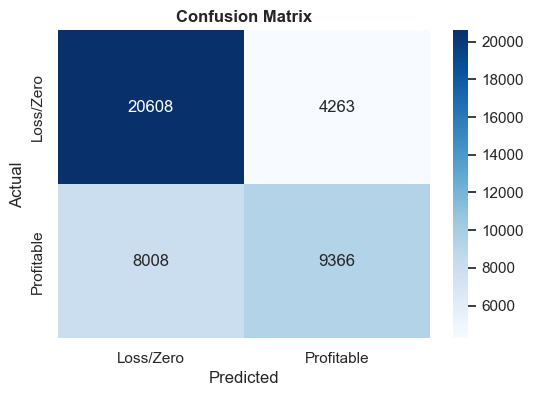

In [74]:
#Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss/Zero', 'Profitable'], 
            yticklabels=['Loss/Zero', 'Profitable'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

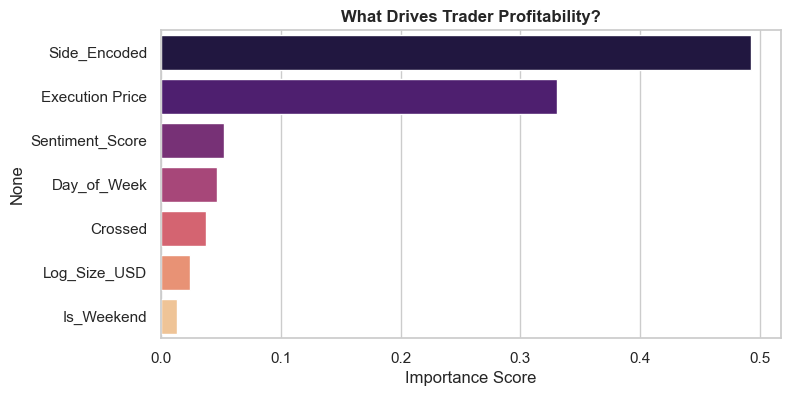

In [75]:
#Feature Importance (What drives profitability?)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('What Drives Trader Profitability?', fontweight='bold')
plt.xlabel('Importance Score')
plt.show()

Model Accuracy: 70.95%

**Classification Report**
              precision    recall  f1-score   support

           0       0.72      0.83      0.77     24871
           1       0.69      0.54      0.60     17374

    accuracy                           0.71     42245
   macro avg       0.70      0.68      0.69     42245
weighted avg       0.71      0.71      0.70     42245



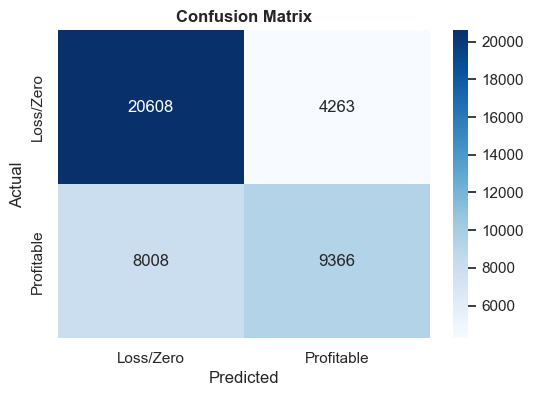

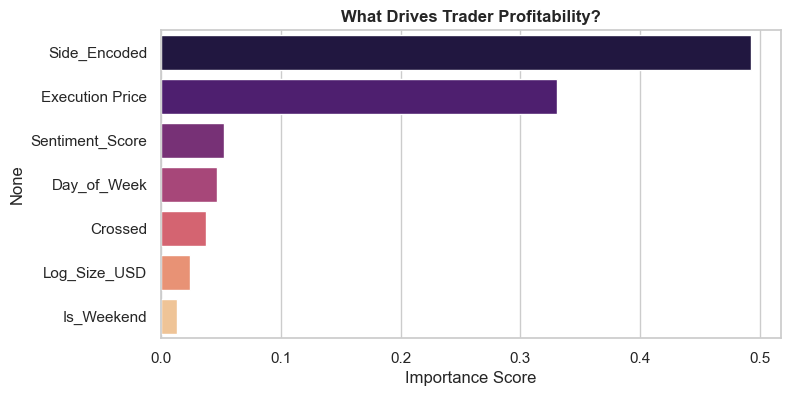

In [70]:
# ==========================================

# ==========================================









